# Conformer Sampling

#TODO exercise info

![title](alanine_dipeptide.png)

In [17]:
import os, sys

os.environ["TORCH_COMPILE_DISABLE"] = "1"

sys.path.insert(0, os.path.dirname(os.path.dirname(os.getcwd())))

In [18]:
import demo_tools.generate_adp_conformers as conf_sampling
import demo_tools.align_geometries as align_geometries

In [19]:
# conf_sampling.load_mols loads the molecular conformers from an XYZ file using ase.io.read(xyzfile, index=":")
mols = conf_sampling.load_mols('alanine_dipeptide_conformers.xyz')

In [ ]:
from Psience.Molecools import Molecule
import McUtils.Plots as plt

Molecule.from_ase(mols[0]).plot(
    backend='x3d',
    background='white',
    navigation={'headlight':True},
    environment={'reflectionIntensity': 1.0},
    atom_style={'ambientIntensity': 0.2, 'specularColor': (0.38, 0.38, 0.38), 'shininess': 0.32},
    bond_style={'ambientIntensity': 0.2, 'specularColor': (0.38, 0.38, 0.38), 'shininess': 0.32},
    lighting=[
        {'direction': (-0.45, -0.65, -1.0), 'color': (1.0, 0.98, 0.95),
         'intensity': 0.2, 'ambientIntensity': 0.16, 'global': True},
        {'direction': (0.70, 0.20, -1.0), 'color': (0.90, 0.94, 1.0),
         'intensity': 0.2, 'ambientIntensity': 0.05, 'global': True},
    ],
    # use_xite=True,
    image_size=800,
    display_atom_numbers=True,
    # highlight_atoms=psi_indices
)#.to_widget().write("/Users/Mark/Downloads/anim_xite.html")

In [23]:
phi_indices = [1,3,4,6][::-1]
phi_rotation_indices = [13,0,1,2,10,11,12]
psi_indices = [3,4,6,8]
psi_rotation_indices = [7,8,9,18,19,20,21]
central_cccn = [3,4,5,6]

def get_phi(mol, phi_indices=phi_indices):
    return mol.get_dihedral(
        *phi_indices
    )

def get_psi(mol, psi_indices = psi_indices):
    return mol.get_dihedral(
        *psi_indices
    )

In [24]:
aligned_mols = align_geometries.align_atoms_list(
    geometries=mols,
    atom_indices=central_cccn,
    reference_index=0
)

In [ ]:
combined_mols = aligned_mols[0].copy()
for mol in aligned_mols[1:]:
    combined_mols.extend(mol)
from ase.visualize import view
view(combined_mols,viewer="x3d")

In [ ]:
opt_mols = [mol.copy() for mol in aligned_mols]
for mol in opt_mols:
    mol.calc = calculator
    dyn = BFGS(mol)
    dyn.run(fmax=0.01)


In [ ]:
aligned_opt_mols = align_geometries.align_atoms_list(
    geometries=opt_mols,
    atom_indices=central_cccn,
    reference_index=0
)

combined_opt_mols = aligned_opt_mols[0].copy()
for mol in aligned_opt_mols[1:]:
    combined_opt_mols += mol.copy()

view(combined_opt_mols,viewer='x3d')

In [79]:
# Make 2D PES with *rigid* scans
from aimnet.calculators import AIMNet2ASE
from ase.optimize import BFGS

calculator = AIMNet2ASE('aimnet2', 
                  charge=0,
                  )
from ase.constraints import FixInternals
rigid_scan_mol = mols[0].copy()
rigid_scan_mol.calc = calculator

rigid_scan_data = []
rigid_scan_structs = []

for phi in range(-180,181, 10):
    rigid_scan_mol.set_dihedral(*phi_indices, phi, indices= phi_rotation_indices)
    for psi in range(-180,181, 10):
        rigid_scan_mol.set_dihedral(*psi_indices, psi, indices= psi_rotation_indices)
        rigid_scan_data.append((phi, psi, rigid_scan_mol.get_potential_energy()))
        rigid_scan_mol.info['phi'] = phi
        rigid_scan_mol.info['psi'] = psi
        rigid_scan_mol.info['Energy'] = rigid_scan_mol.get_potential_energy()
        rigid_scan_structs.append(rigid_scan_mol.copy())
all_rigid_scan_structs = rigid_scan_structs[0].copy()
for struct in rigid_scan_structs[1:]:
    all_rigid_scan_structs.extend(struct)
    

In [80]:
from ase.io import write
write('Rigid_scan_structures.xyz', rigid_scan_structs, format='extxyz')

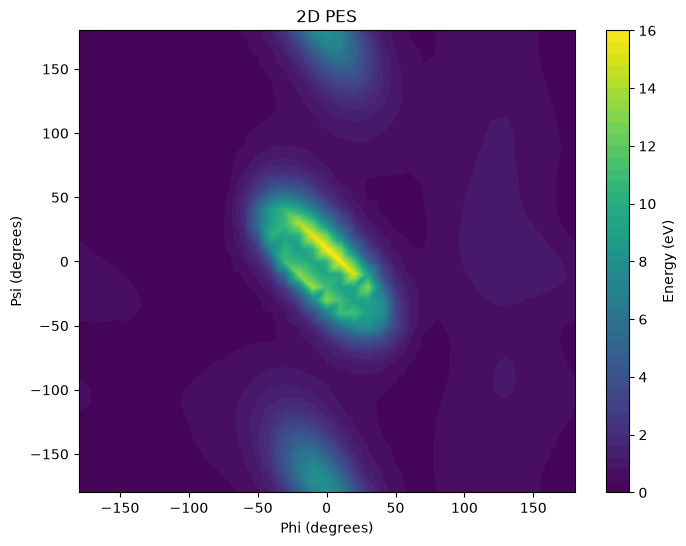

In [84]:
import matplotlib.pyplot as plt
import numpy as np
rigid_scan_data = np.array(rigid_scan_data)
phi = rigid_scan_data[:,0]
psi = rigid_scan_data[:,1]
energy = rigid_scan_data[:,2]

# Create a 2D potential energy surface plot
plt.figure(figsize=(8,6))
plt.tricontourf(phi, psi, energy - np.min(energy), levels=50, cmap='viridis')
plt.colorbar(label='Energy (eV)')
plt.xlabel('Phi (degrees)')
plt.ylabel('Psi (degrees)')
plt.title('2D PES')
plt.show()

## Do 1D relaxed scan of phi (~2 minutes runtime)

We are going to do a 2D PES scan.  We will first do a 1D iterative (see note $^{\ddagger}$) scan over $\Phi$, then we will follow this up with an iterative scan over $\Psi$ for each $\Phi$, which we will do in parallel. 


$^{\ddagger}$ i.e. We start with ($\Phi, \Psi$)=(-180,-180).  Optimize this structure.  Then, take that optimized structure and rotate $\Phi$ 10 degrees and optimize it.  Then take that optimized structure and rotate $\Phi$ 10 degrees again and optimize again... until $\Phi$=+180. The alternative was to take all structures from the rigid scan and optimize them all in parallel. However, this led to some convergence errors and/or unrealistic geometries/energies. Doing it iteratively safely finds sensible structures and avoids convergence problems.

In [ ]:
# Define our calculator
calculator = AIMNet2ASE('aimnet2', 
                  charge=0,
                  )

# Import necessary modules for constraints and optimization
from ase.constraints import FixInternals
from ase.optimize import BFGS
from ase.io import write

# Prepare the initial relaxed scan molecule by copying one of our conformers and setting the dihedrals
relaxed_scan_mol = mols[0].copy()
relaxed_scan_mol.set_dihedral(*phi_indices, -190, indices= phi_rotation_indices)
relaxed_scan_mol.set_dihedral(*psi_indices, -180, indices= psi_rotation_indices)

# Get relaxed phi structures from -180 to 180 degrees, holding psi at -180
phi_1D_scan_structures = []
phi_1d_struct = relaxed_scan_mol.copy()
for i,phi in enumerate(range(-180, 181, 10)):
    # Remove any constraints on the Atoms object
    phi_1d_struct.set_constraint()

    # Attach the calculator to the Atoms object
    phi_1d_struct.calc = calculator

    # Rotate the phi dihedral by 10 degrees
    phi_1d_struct.rotate_dihedral(*phi_indices, 10, indices= phi_rotation_indices)

    # Apply constraints to the dihedrals
    phi_1d_struct.set_constraint(FixInternals(dihedrals_deg=[(phi, phi_indices), (-180, psi_indices)]))

    # Optimize
    dyn = BFGS(phi_1d_struct)
    dyn.run(fmax=0.01)

    # Store the relaxed structure and its associated data
    phi_1d_struct.info['target_phi'] = phi
    phi_1d_struct.info['target_psi'] = -180
    phi_1d_struct.info['actual_phi'] = phi_1d_struct.get_dihedral(*phi_indices)
    phi_1d_struct.info['actual_psi'] = phi_1d_struct.get_dihedral(*psi_indices)
    phi_1d_struct.info['Energy'] = phi_1d_struct.get_potential_energy()
    phi_1D_scan_structures.append(phi_1d_struct.copy())

# Write the relaxed phi scan structures to an EXTXYZ file
write(phi_1D_scan_structures, 'phi_1D_scan_structures.xyz', format='extxyz')

      Step     Time          Energy          fmax
BFGS:    0 18:20:03   -13501.935931        1.462798
BFGS:    1 18:20:03   -13501.989681        1.048552
BFGS:    2 18:20:03   -13502.010800        0.566344
BFGS:    3 18:20:03   -13502.029366        0.367284
BFGS:    4 18:20:03   -13502.042463        0.292703
BFGS:    5 18:20:03   -13502.054935        0.298213
BFGS:    6 18:20:03   -13502.064657        0.261940
BFGS:    7 18:20:03   -13502.072133        0.192895
BFGS:    8 18:20:03   -13502.077318        0.198177
BFGS:    9 18:20:03   -13502.081945        0.209786
BFGS:   10 18:20:03   -13502.086353        0.185920
BFGS:   11 18:20:03   -13502.090801        0.150422
BFGS:   12 18:20:03   -13502.094466        0.118897
BFGS:   13 18:20:03   -13502.097169        0.129742
BFGS:   14 18:20:03   -13502.099983        0.122460
BFGS:   15 18:20:03   -13502.102156        0.087049
BFGS:   16 18:20:03   -13502.103690        0.080711
BFGS:   17 18:20:04   -13502.104934        0.099401
BFGS:   18 18:

## 2D relaxed scan (Run parallel_relaxed_scan.py on the command line in the folder ConformerSampling)

This should do a scan over $\Psi$ for each structure from the 1D scan over $\Phi$, and generates 'Relaxed_2D_scan.xyz'

In [118]:
from ase.io import read
relaxed_2d_structures = read('relaxed_2D_scan.xyz', index=':', format='extxyz')

In [121]:
view(relaxed_2d_structures)

<Popen: returncode: None args: ['/root/miniconda3/envs/wsl_mlip_aimnet/bin/p...>

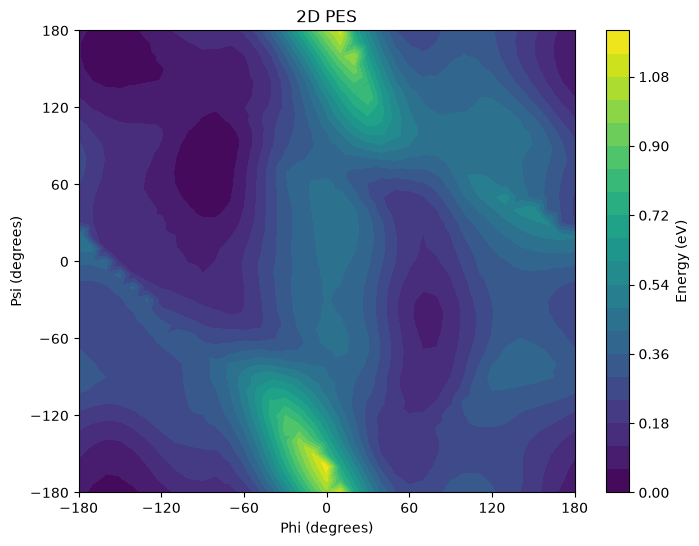

In [122]:
phis = []
psis = []
es = []
for structure in relaxed_2d_structures:
    phis.append(structure.info["target_phi"])
    psis.append(structure.info["target_psi"])
    es.append(structure.info["Energy"])


relaxed_scan_data = np.array(list(zip(phis, psis, es)))
phi = relaxed_scan_data[:,0]
psi = relaxed_scan_data[:,1]
energy = relaxed_scan_data[:,2] - np.min(relaxed_scan_data[:,2])

# Create a 2D potential energy surface plot
plt.figure(figsize=(8,6))
plt.tricontourf(phi, psi, energy, levels=20, cmap='viridis')
plt.colorbar(label='Energy (eV)')
plt.xlabel('Phi (degrees)')
plt.ylabel('Psi (degrees)')
plt.title('2D PES')

plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xticks(np.arange(-180, 181, 60))
plt.yticks(np.arange(-180, 181, 60))
plt.show()


# Check where our relaxed conformers lie on the 2D PES

/tmp/ipykernel_83633/737136253.py:34: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(phi, psi, c='white', cmap='viridis', edgecolor='k')


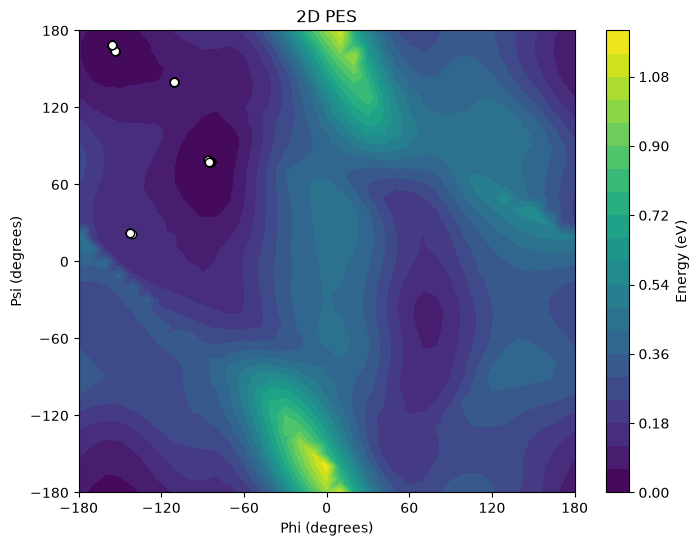

In [125]:
phis = []
psis = []
es = []
for structure in relaxed_2d_structures:
    phis.append(structure.info["target_phi"])
    psis.append(structure.info["target_psi"])
    es.append(structure.info["Energy"])


relaxed_scan_data = np.array(list(zip(phis, psis, es)))
phi = relaxed_scan_data[:,0]
psi = relaxed_scan_data[:,1]
energy = relaxed_scan_data[:,2] - np.min(relaxed_scan_data[:,2])

# Create a 2D potential energy surface plot
plt.figure(figsize=(8,6))
plt.tricontourf(phi, psi, energy, levels=20, cmap='viridis')
plt.colorbar(label='Energy (eV)')
plt.xlabel('Phi (degrees)')
plt.ylabel('Psi (degrees)')
plt.title('2D PES')

plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.xticks(np.arange(-180, 181, 60))
plt.yticks(np.arange(-180, 181, 60))

def convert_angle(angle):
    return (angle + 180) % 360 - 180

for struct in opt_mols:
    phi = convert_angle(struct.get_dihedral(*phi_indices))
    psi = convert_angle(struct.get_dihedral(*psi_indices))
    plt.scatter(phi, psi, c='white', cmap='viridis', edgecolor='k')

# for struct in mols:
#     phi = convert_angle(struct.get_dihedral(*phi_indices))
#     psi = convert_angle(struct.get_dihedral(*psi_indices))
#     plt.scatter(phi, psi, c='red', cmap='viridis', edgecolor='k')

plt.show()
